# Project 1 — Chest X-Ray Analysis

## Goal
Process and analyze chest X-ray scans using classical computer vision
techniques to highlight lung regions, detect structural boundaries, and isolate
areas of interest — simulating the preprocessing stage of a real medical AI
pipeline for thoracic radiology.

## Disease Description
The **NIH Chest X-Ray Dataset** contains scans labeled with 14 thoracic
diseases including Pneumonia, Pleural Effusion, Cardiomegaly, Atelectasis,
and Nodules among others. Chest X-ray is one of the most commonly performed
medical imaging procedures globally and accurate automated analysis of these
scans is a critical problem in clinical AI.

## Dataset
NIH Chest X-Ray Dataset
Source: kaggle.com/datasets/nih-chest-xrays/data
Total images: 112,120 chest X-rays from 30,805 unique patients
Labels: 14 disease classes + No Finding
Format: PNG 1024x1024

## Techniques Applied
- Grayscale conversion
- CLAHE contrast enhancement
- Binary thresholding
- Morphological operations (opening & closing)
- Canny edge detection
- Contour detection and drawing

## Expected Output
A side by side comparison showing the original scan, enhanced image,
detected edges, and contours drawn over the lung and structural regions.Sonnet 4.6Claude is 

## IMAGE 1 (0.jpg) - Lateral Chest X-Ray (Overexposed)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
import cv2

In [2]:
color_img = cv2.imread('DATA/0.jpg')

In [3]:
gray_img = cv2.imread('DATA/0.JPG',0)

In [4]:
## Contrast enhancement
im = cv2.equalizeHist(gray_img)

In [7]:
## Apply Thresholding

ret,thresh = cv2.threshold(im,127,255,cv2.THRESH_BINARY_INV)

In [8]:
## Detect Edges

blurred = cv2.GaussianBlur(thresh,(5,5),0)
edges = cv2.Canny(blurred, 20,80)


In [9]:
## Find and Draw Contours

copy = color_img.copy()

contours, hierachy = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(copy,contours,-1,(0,255,0),5)

array([[[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

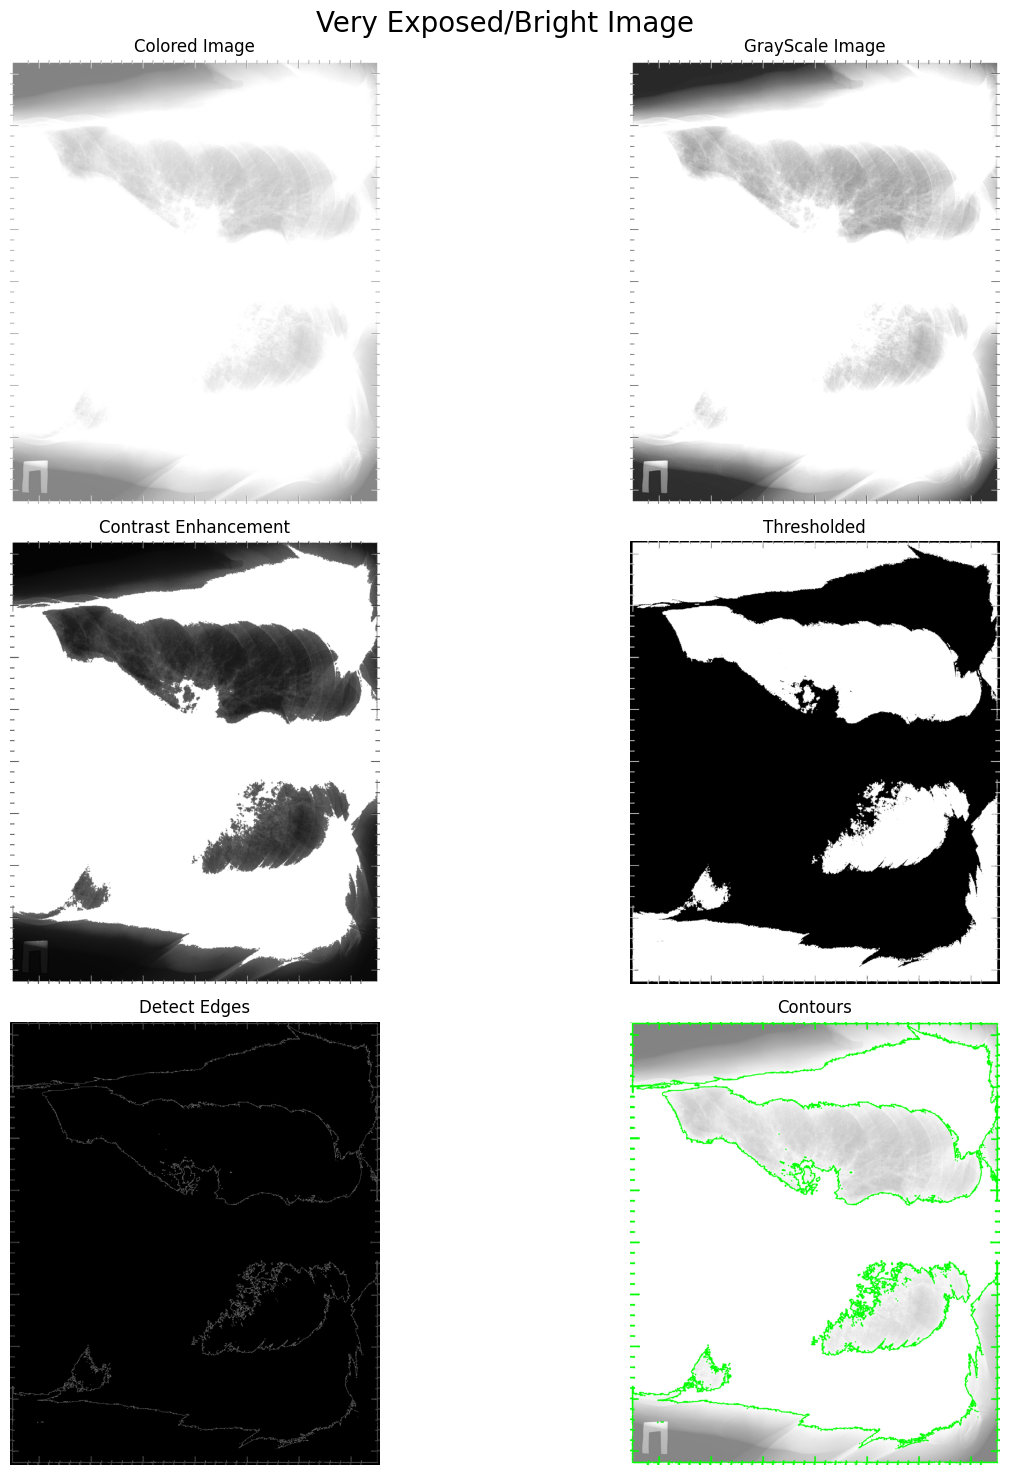

In [10]:
plt.figure(figsize=(15,15))

plt.subplot(321);plt.imshow(color_img);plt.title("Colored Image");plt.axis("off")
plt.subplot(322);plt.imshow(gray_img,cmap='gray');plt.title("GrayScale Image");plt.axis("off")
plt.subplot(323);plt.imshow(im,cmap='gray');plt.title("Contrast Enhancement");plt.axis("off")
plt.subplot(324);plt.imshow(thresh,cmap='gray');plt.title("Thresholded");plt.axis("off")
plt.subplot(325);plt.imshow(edges,cmap='gray');plt.title("Detect Edges");plt.axis("off")
plt.subplot(326);plt.imshow(copy,cmap='gray');plt.title("Contours");plt.axis("off")

plt.suptitle("Very Exposed/Bright Image", fontsize = 20)
plt.tight_layout()
plt.show()


## IMAGE 2 (1.jpg) - Clean Frontal Chest X-Ray

In [11]:
color_img = cv2.imread('Data/1.jpg')
color_img = cv2.cvtColor(color_img,cv2.COLOR_BGR2RGB)

In [12]:
gray_img = cv2.imread('Data/1.jpg', 0)

In [13]:
## Apply Thresholding

ret, thresh = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY_INV)

In [14]:
## Morphological Operator

kernel = np.ones((5,5),np.uint8)

cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

In [15]:
## Find Contours of both lungs
copy = color_img.copy()

contours, hierachy = cv2.findContours(cleaned, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
#cv2.drawContours(copy,contours,-1,(255,0,0),5)
# bounding = sorted(contours,key=cv2.contourArea , reverse=True)[:2]
contours = sorted(contours,key=cv2.contourArea , reverse=True)
largest_two = contours[:2]

for cnt in largest_two:
    x,y,w,h = cv2.boundingRect(cnt)
    cv2.rectangle(copy, (x,y), (x+w, y+h), (255,0,0),2)
    area = cv2.contourArea(cnt)
    cv2.putText(copy,f'Area:{int(area)}', (x, y-10),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),1)
    

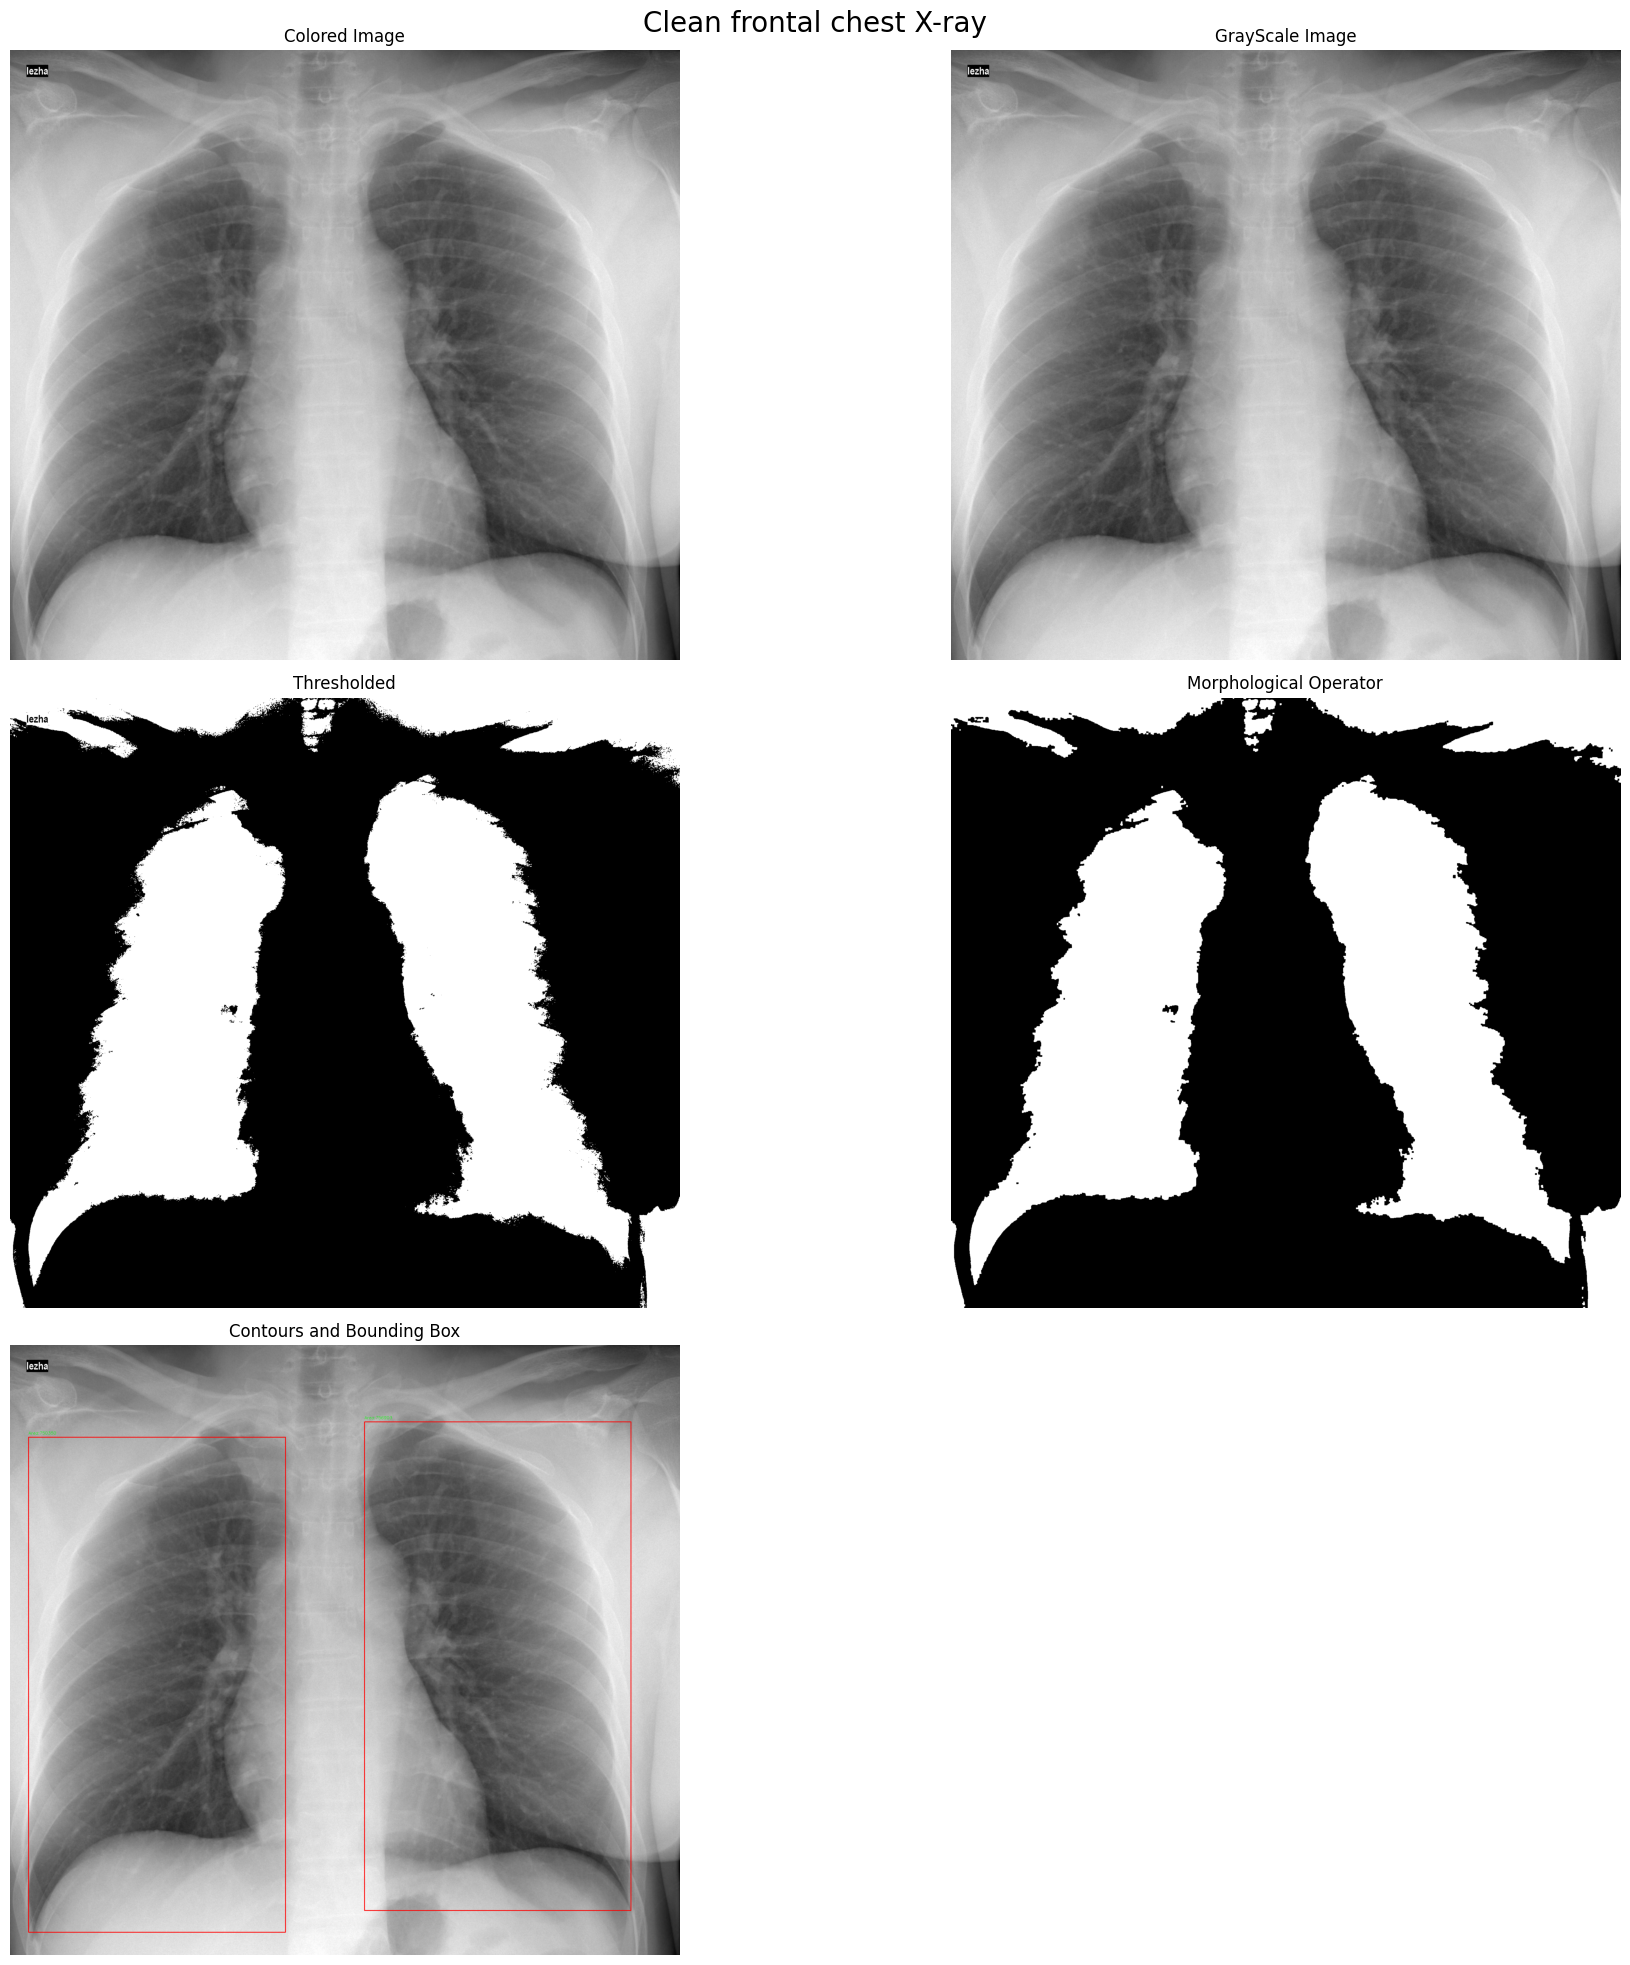

Lung 1 area: 756903 pixels
Lung 2 area: 750350 pixels


In [16]:
plt.figure(figsize=(20,20))

plt.subplot(321);plt.imshow(color_img);plt.title("Colored Image");plt.axis("off")
plt.subplot(322);plt.imshow(gray_img,cmap='gray');plt.title("GrayScale Image");plt.axis("off")
plt.subplot(323);plt.imshow(thresh,cmap='gray');plt.title("Thresholded");plt.axis("off")
plt.subplot(324);plt.imshow(cleaned,cmap='gray');plt.title("Morphological Operator");plt.axis("off")
plt.subplot(325);plt.imshow(copy,cmap='gray');plt.title("Contours and Bounding Box");plt.axis("off")

plt.suptitle("Clean frontal chest X-ray", fontsize = 20)
plt.tight_layout()
plt.show()

for i, cnt in enumerate (largest_two):
    print(f"Lung {i+1} area: {int(cv2.contourArea(cnt))} pixels")


## IMAGE 3 (2.jpg) - Cardiomegaly (Enlarged Heart)

In [17]:
color_img = cv2.imread('Data/2.jpg')


In [58]:
gray_img = cv2.imread('Data/2.jpg',0)

In [52]:
## Apply Thresholding

ret,thresh = cv2.threshold(gray_img,150,255,cv2.THRESH_BINARY)

In [57]:
## Morphological Operator

kernel = np.ones((7,7),np.uint8)
cleaned = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel)
cleaned = cv2.morphologyEx(cleaned,cv2.MORPH_CLOSE,kernel)

Heart width: 1947px
Chest width: 2272px
Cardiothoracic Ratio: 0.86


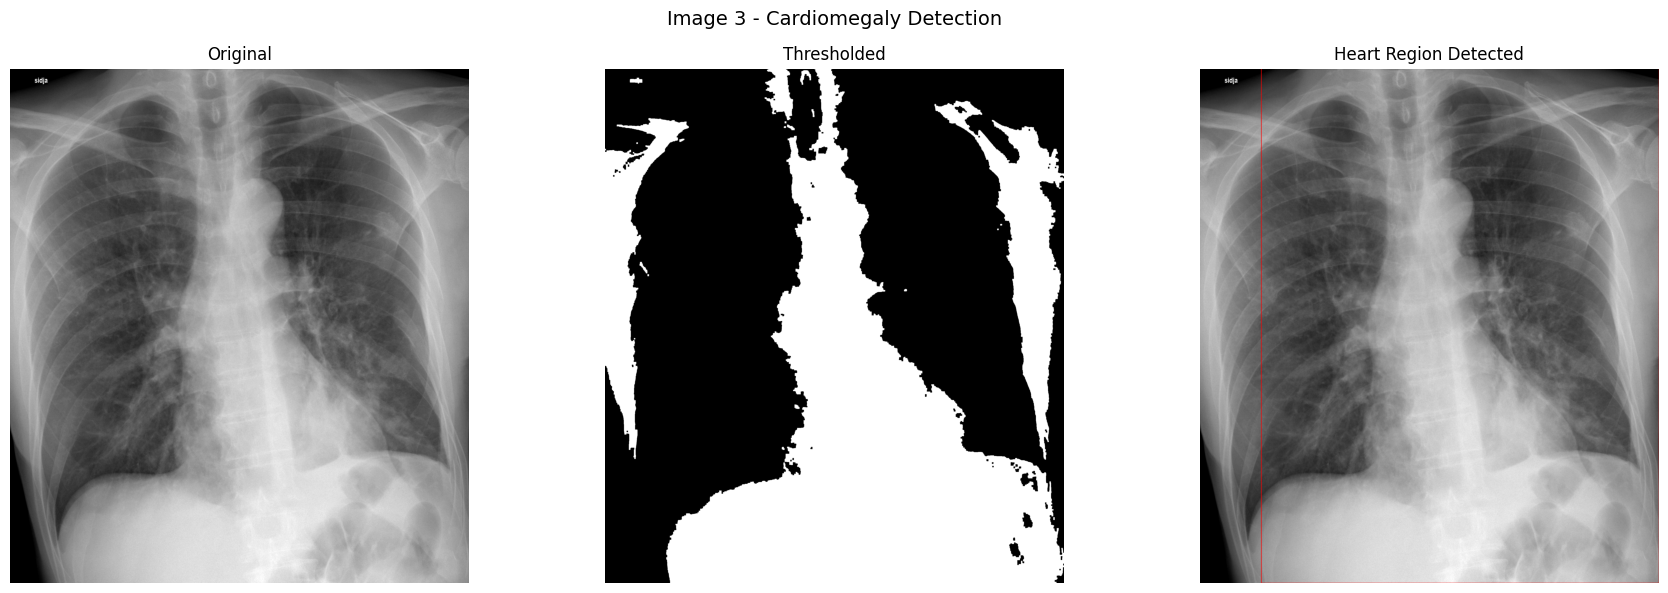

In [59]:
## Find the Largest Contour
copy3 = color_img.copy()

contours, hierachy = cv2.findContours(cleaned, cv2.RETR_LIST,cv2.CHAIN_APPROX_SIMPLE)
contours_sorted = sorted(contours, key=cv2.contourArea,reverse=True)
largest= contours_sorted[0]

## Draw a bounding box around it
x,y,w,h = cv2.boundingRect(largest)
cv2.rectangle(copy3,(x,y),(x+w,y+h),(255,0,0),2)

# Cardiothoracic ratio
chest_width = img2.shape[1]
heart_width = w
ct_ratio = heart_width / chest_width
print(f"Heart width: {heart_width}px")
print(f"Chest width: {chest_width}px")
print(f"Cardiothoracic Ratio: {ct_ratio:.2f}")
if ct_ratio > 0.5:
    print("WARNING: CT Ratio > 0.5 — Possible Cardiomegaly")
else:
    print("CT Ratio normal")

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(img2, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cleaned2, cmap='gray')
axes[1].set_title('Thresholded')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(img2_color, cv2.COLOR_BGR2RGB))
axes[2].set_title('Heart Region Detected')
axes[2].axis('off')
plt.suptitle('Image 3 - Cardiomegaly Detection', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# IMAGE 1 (0.jpg) - Lateral Chest X-Ray (Overexposed)
# ============================================================

img0 = cv2.imread('data/0.jpg', cv2.IMREAD_GRAYSCALE)

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
enhanced0 = clahe.apply(img0)

_, thresh0 = cv2.threshold(enhanced0, 127, 255, cv2.THRESH_BINARY_INV)

kernel = np.ones((3,3), np.uint8)
cleaned0 = cv2.morphologyEx(thresh0, cv2.MORPH_OPEN, kernel)
cleaned0 = cv2.morphologyEx(cleaned0, cv2.MORPH_CLOSE, kernel)

edges0 = cv2.Canny(enhanced0, 30, 100)

contours0, _ = cv2.findContours(edges0, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img0_color = cv2.cvtColor(img0, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img0_color, contours0, -1, (0,255,0), 1)

fig, axes = plt.subplots(1, 4, figsize=(20,5))
axes[0].imshow(img0, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(enhanced0, cmap='gray')
axes[1].set_title('CLAHE Enhanced')
axes[1].axis('off')
axes[2].imshow(edges0, cmap='gray')
axes[2].set_title('Canny Edges')
axes[2].axis('off')
axes[3].imshow(cv2.cvtColor(img0_color, cv2.COLOR_BGR2RGB))
axes[3].set_title('Contours')
axes[3].axis('off')
plt.suptitle('Image 1 - Lateral Chest X-Ray (Overexposed)', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Image 1 - Total structures detected: {len(contours0)}")


# ============================================================
# IMAGE 2 (1.jpg) - Clean Frontal Chest X-Ray
# ============================================================

img1 = cv2.imread('data/1.jpg', cv2.IMREAD_GRAYSCALE)

_, thresh1 = cv2.threshold(img1, 80, 255, cv2.THRESH_BINARY_INV)

kernel = np.ones((5,5), np.uint8)
cleaned1 = cv2.morphologyEx(thresh1, cv2.MORPH_OPEN, kernel)
cleaned1 = cv2.morphologyEx(cleaned1, cv2.MORPH_CLOSE, kernel)

contours1, _ = cv2.findContours(cleaned1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours by area — largest two are the lungs
contours1_sorted = sorted(contours1, key=cv2.contourArea, reverse=True)[:2]

img1_color = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
for cnt in contours1_sorted:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(img1_color, (x,y), (x+w, y+h), (0,255,0), 2)
    area = cv2.contourArea(cnt)
    cv2.putText(img1_color, f'Area:{int(area)}', (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(img1, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cleaned1, cmap='gray')
axes[1].set_title('Thresholded & Cleaned')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(img1_color, cv2.COLOR_BGR2RGB))
axes[2].set_title('Lung Bounding Boxes')
axes[2].axis('off')
plt.suptitle('Image 2 - Frontal Chest X-Ray Lung Detection', fontsize=14)
plt.tight_layout()
plt.show()

for i, cnt in enumerate(contours1_sorted):
    print(f"Lung {i+1} area: {int(cv2.contourArea(cnt))} pixels")


# ============================================================
# IMAGE 3 (2.jpg) - Cardiomegaly (Enlarged Heart)
# ============================================================

img2 = cv2.imread('data/2.jpg', cv2.IMREAD_GRAYSCALE)

_, thresh2 = cv2.threshold(img2, 150, 255, cv2.THRESH_BINARY)

kernel = np.ones((7,7), np.uint8)
cleaned2 = cv2.morphologyEx(thresh2, cv2.MORPH_CLOSE, kernel)
cleaned2 = cv2.morphologyEx(cleaned2, cv2.MORPH_OPEN, kernel)

contours2, _ = cv2.findContours(cleaned2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Largest contour = heart region
contours2_sorted = sorted(contours2, key=cv2.contourArea, reverse=True)
heart_contour = contours2_sorted[0]

img2_color = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)
x, y, w, h = cv2.boundingRect(heart_contour)
cv2.rectangle(img2_color, (x,y), (x+w, y+h), (0,0,255), 2)
cv2.putText(img2_color, 'Heart Region', (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)

# Cardiothoracic ratio
chest_width = img2.shape[1]
heart_width = w
ct_ratio = heart_width / chest_width
print(f"Heart width: {heart_width}px")
print(f"Chest width: {chest_width}px")
print(f"Cardiothoracic Ratio: {ct_ratio:.2f}")
if ct_ratio > 0.5:
    print("WARNING: CT Ratio > 0.5 — Possible Cardiomegaly")
else:
    print("CT Ratio normal")

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(img2, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cleaned2, cmap='gray')
axes[1].set_title('Thresholded')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(img2_color, cv2.COLOR_BGR2RGB))
axes[2].set_title('Heart Region Detected')
axes[2].axis('off')
plt.suptitle('Image 3 - Cardiomegaly Detection', fontsize=14)
plt.tight_layout()
plt.show()


# ============================================================
# IMAGE 4 (3.jpg) - Lateral Left Chest (Rib Detection)
# ============================================================

img3 = cv2.imread('data/3.jpg', cv2.IMREAD_GRAYSCALE)

clahe3 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced3 = clahe3.apply(img3)

edges3 = cv2.Canny(enhanced3, 50, 150)

# HoughLinesP to detect rib lines
lines = cv2.HoughLinesP(edges3, rho=1, theta=np.pi/180,
                         threshold=80, minLineLength=60, maxLineGap=10)

img3_color = cv2.cvtColor(img3, cv2.COLOR_GRAY2BGR)
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img3_color, (x1,y1), (x2,y2), (0,255,0), 1)

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(img3, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(edges3, cmap='gray')
axes[1].set_title('Canny Edges')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(img3_color, cv2.COLOR_BGR2RGB))
axes[2].set_title('Rib Lines Detected')
axes[2].axis('off')
plt.suptitle('Image 4 - Lateral Chest Rib Detection', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Rib lines detected: {len(lines) if lines is not None else 0}")


# ============================================================
# IMAGE 5 (4.jpg) - Frontal Chest (Left vs Right Lung)
# ============================================================

img4 = cv2.imread('data/4.jpg', cv2.IMREAD_GRAYSCALE)

_, thresh4 = cv2.threshold(img4, 80, 255, cv2.THRESH_BINARY_INV)

kernel = np.ones((5,5), np.uint8)
cleaned4 = cv2.morphologyEx(thresh4, cv2.MORPH_OPEN, kernel)
cleaned4 = cv2.morphologyEx(cleaned4, cv2.MORPH_CLOSE, kernel)

contours4, _ = cv2.findContours(cleaned4, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours4_sorted = sorted(contours4, key=cv2.contourArea, reverse=True)[:2]

img4_color = cv2.cvtColor(img4, cv2.COLOR_GRAY2BGR)

# Separate left and right lung by x position
contours4_sorted_x = sorted(contours4_sorted, key=lambda c: cv2.boundingRect(c)[0])
colors = [(0,255,0), (255,0,0)]   # green = left, blue = right
labels = ['Left Lung', 'Right Lung']

areas = []
for i, cnt in enumerate(contours4_sorted_x):
    cv2.drawContours(img4_color, [cnt], -1, colors[i], 2)
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.putText(img4_color, labels[i], (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, colors[i], 2)
    areas.append(cv2.contourArea(cnt))

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(img4, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(cleaned4, cmap='gray')
axes[1].set_title('Thresholded & Cleaned')
axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(img4_color, cv2.COLOR_BGR2RGB))
axes[2].set_title('Left vs Right Lung')
axes[2].axis('off')
plt.suptitle('Image 5 - Left vs Right Lung Comparison', fontsize=14)
plt.tight_layout()
plt.show()

if len(areas) == 2:
    diff = abs(areas[0] - areas[1])
    pct = (diff / max(areas)) * 100
    larger = labels[0] if areas[0] > areas[1] else labels[1]
    print(f"Left Lung area:  {int(areas[0])} pixels")
    print(f"Right Lung area: {int(areas[1])} pixels")
    print(f"{larger} is larger by {pct:.1f}%")


# ============================================================
# IMAGE 6 (5.jpg) - Lateral Chest with Medical Device
# ============================================================

img5 = cv2.imread('data/5.jpg', cv2.IMREAD_GRAYSCALE)

clahe5 = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
enhanced5 = clahe5.apply(img5)

_, thresh5 = cv2.threshold(img5, 127, 255, cv2.THRESH_BINARY_INV)

kernel = np.ones((3,3), np.uint8)
cleaned5 = cv2.morphologyEx(thresh5, cv2.MORPH_OPEN, kernel)

edges5 = cv2.Canny(enhanced5, 30, 100)

# Isolate bright medical device with high threshold
_, device_mask = cv2.threshold(img5, 220, 255, cv2.THRESH_BINARY)
device_contours, _ = cv2.findContours(device_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img5_color = cv2.cvtColor(img5, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img5_color, device_contours, -1, (0,0,255), 2)

fig, axes = plt.subplots(1, 4, figsize=(20,5))
axes[0].imshow(img5, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(enhanced5, cmap='gray')
axes[1].set_title('CLAHE Enhanced')
axes[1].axis('off')
axes[2].imshow(edges5, cmap='gray')
axes[2].set_title('Canny Edges')
axes[2].axis('off')
axes[3].imshow(cv2.cvtColor(img5_color, cv2.COLOR_BGR2RGB))
axes[3].set_title('Medical Device Highlighted')
axes[3].axis('off')
plt.suptitle('Image 6 - Lateral Chest with Medical Device Detection', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Medical device contours detected: {len(device_contours)}")